In [1]:
import sys
print(sys.executable)

d:\Miniconda3\envs\duke_rob\python.exe


Setup

In [ ]:
import gymnasium as gym
import metaworld 

env = gym.make("Meta-World/MT1", env_name="peg-insert-side-v3", seed=0)

# --- Flag 1: is a TimeLimit already applied? ---
print("env spec:", env.spec)
print("max_episode_steps (via spec):",
      env.spec.max_episode_steps if env.spec else "not set on spec")

# Walk the wrapper stack to see if TimeLimit is already present
w = env
depth = 0
while hasattr(w, "env"):
    print(f"  wrapper[{depth}]: {type(w).__name__}")
    if type(w).__name__ == "TimeLimit":
        print(f"    -> TimeLimit found, _max_episode_steps = {w._max_episode_steps}")
    w = w.env
    depth += 1
print(f"  wrapper[{depth}] (base): {type(w).__name__}")

# --- Flag 2: does info contain "success"? ---
obs, info = env.reset()
print("\nreset() info keys:", list(info.keys()))

action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)
print("step() info keys:", list(info.keys()))
print("success value on random action:", info.get("success", "KEY NOT FOUND"))
print("reward:", reward, "terminated:", terminated, "truncated:", truncated)

env.close()

In [9]:
import gymnasium as gym
import metaworld

TASK_NAME = "peg-insert-side-v3"

def make_env(seed=0, render_mode=None):
    env = gym.make(
        "Meta-World/MT1",
        env_name=TASK_NAME,
        seed=seed,
        render_mode=render_mode,
    )
    return env

def env_fn(rank):
    def _init():
        return make_env(seed=rank)
    return _init

In [10]:
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

N_ENVS = 4  # tune down if RAM/CPU constrained; check with os.cpu_count()

train_env = DummyVecEnv([env_fn(i) for i in range(N_ENVS)])
train_env = VecMonitor(train_env)

eval_env = make_env(seed=1000)

In [ ]:
from stable_baselines3 import SAC

model = SAC(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    buffer_size=1_000_000,
    batch_size=256, # gradient
    tau=0.005, # soft update of target network, prevent osscillation
    gamma=0.99, # discount factor, focus on long-term
    train_freq=1, 
    gradient_steps=1,
    ent_coef="auto",
    policy_kwargs=dict(net_arch=[400, 400]),
    tensorboard_log="./tb_logs/peg_insert_side",
    verbose=1,
    seed=0,
    device="auto", 
)

Using cpu device


In [ ]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np
import os, json, time

SUCCESS_KEY = "success"  # <-- change this if step 2 found a different key name

class SuccessAndTimeToSuccessCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=10_000, n_eval_episodes=10,
                 ckpt_dir="./checkpoints", ckpt_freq=100_000, max_ep_steps=500,
                 verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.ckpt_dir = ckpt_dir
        self.ckpt_freq = ckpt_freq
        self.max_ep_steps = max_ep_steps
        os.makedirs(ckpt_dir, exist_ok=True)
        self.history = []

    # Run a single evaluation episode and return the step at which success occurred (or None)
    def _run_eval_episode(self):
        obs, _ = self.eval_env.reset()
        success_step = None
        for t in range(self.max_ep_steps):
            action, _ = self.model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = self.eval_env.step(action)
            if info.get(SUCCESS_KEY, 0) and success_step is None:
                success_step = t
            if terminated or truncated:
                break
        return success_step


    def _on_step(self) -> bool:
        if self.n_calls % self.ckpt_freq == 0:
            path = os.path.join(self.ckpt_dir, f"sac_peg_insert_{self.n_calls}.zip")
            self.model.save(path)
            if self.verbose:
                print(f"[ckpt] saved {path}")

        if self.n_calls % self.eval_freq == 0:
            success_steps = [self._run_eval_episode() for _ in range(self.n_eval_episodes)]
            n_success = sum(s is not None for s in success_steps)
            success_rate = n_success / self.n_eval_episodes
            times = [s for s in success_steps if s is not None]
            mean_t2s = float(np.mean(times)) if times else None

            self.logger.record("eval/success_rate", success_rate)
            if mean_t2s is not None:
                self.logger.record("eval/mean_time_to_success", mean_t2s)

            self.history.append(dict(
                step=self.n_calls,
                success_rate=success_rate,
                mean_time_to_success=mean_t2s,
                raw_time_to_success=success_steps,
                timestamp=time.time(),
            ))
            with open(os.path.join(self.ckpt_dir, "eval_history.json"), "w") as f:
                json.dump(self.history, f, indent=2)

            if self.verbose:
                print(f"[eval @ {self.n_calls}] success_rate={success_rate:.2f} "
                      f"mean_t2s={mean_t2s}")
        return True

callback = SuccessAndTimeToSuccessCallback(
    eval_env=eval_env,
    eval_freq=10_000,
    n_eval_episodes=10,
    ckpt_dir="./checkpoints/peg_insert_side",
    ckpt_freq=100_000,
)

In [14]:
smoke_callback = SuccessAndTimeToSuccessCallback(
    eval_env=eval_env,
    eval_freq=500,        # small enough to actually trigger within 5k steps
    n_eval_episodes=3,    # fewer episodes, faster smoke test
    ckpt_dir="./checkpoints/peg_insert_side",
    ckpt_freq=2000,
)

model.learn(total_timesteps=5_000, callback=smoke_callback, tb_log_name="smoke_test")

Logging to ./tb_logs/peg_insert_side\smoke_test_2
[eval @ 500] success_rate=0.00 mean_t2s=None
---------------------------------
| eval/              |          |
|    success_rate    | 0        |
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | 5.13     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 128      |
|    time_elapsed    | 15       |
|    total_timesteps | 2000     |
| train/             |          |
|    actor_loss      | -18      |
|    critic_loss     | 0.0242   |
|    ent_coef        | 0.601    |
|    ent_coef_loss   | -3.43    |
|    learning_rate   | 0.0003   |
|    n_updates       | 1699     |
---------------------------------
[eval @ 1000] success_rate=0.00 mean_t2s=None
---------------------------------
| eval/              |          |
|    success_rate    | 0        |
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | 6.08     |
| time/  

In [ ]:
TOTAL_TIMESTEPS = 3_000_000 

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback,
    tb_log_name="sac_run1",
    progress_bar=True,
    reset_num_timesteps=False, 
)

model.save("./checkpoints/peg_insert_side/sac_peg_insert_final")

Logging to ./tb_logs/peg_insert_side\sac_run1_0


Output()

Evaluation

In [1]:
import gymnasium as gym
import metaworld

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"  # match whatever your flag-check found earlier

def make_env(seed=0, render_mode=None):
    env = gym.make(
        "Meta-World/MT1",
        env_name=TASK_NAME,
        seed=seed,
        render_mode=render_mode,
        camera_name="corner3"
    )
    return env

In [2]:
import imageio
import numpy as np
from stable_baselines3 import SAC

model = SAC.load("./checkpoints/peg_insert_side/sac_peg_insert_final")
render_env = make_env(seed=42, render_mode="rgb_array")

def record_successful_rollout(model, env, max_attempts=20, out_path="success3.mp4",
                               extra_frames_after_success=60, fps=20):
    for attempt in range(max_attempts):
        obs, _ = env.reset()
        frames = []
        succeeded = False
        for t in range(500):
            frame = env.render()
            frames.append(np.flipud(frame))  # corner2 renders upside-down; flip before storing
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            if info.get(SUCCESS_KEY, 0) and not succeeded:
                succeeded = True
            if succeeded:
                extra_frames_after_success -= 1
                if extra_frames_after_success <= 0:
                    break
            if terminated or truncated:
                break
        if succeeded:
            imageio.mimsave(out_path, frames, fps=fps)
            print(f"Saved on attempt {attempt+1}/{max_attempts}, {len(frames)} frames: {out_path}")
            return True
    print(f"No success in {max_attempts} attempts.")
    return False

record_successful_rollout(model, render_env)

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Saved on attempt 1/20, 140 frames: success3.mp4


True

In [1]:
from stable_baselines3 import SAC
model = SAC.load("./checkpoints/peg_insert_side/sac_peg_insert_final")

Available tags: ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/actor_loss', 'train/critic_loss', 'train/ent_coef', 'train/ent_coef_loss', 'train/learning_rate', 'eval/success_rate', 'eval/mean_time_to_success']


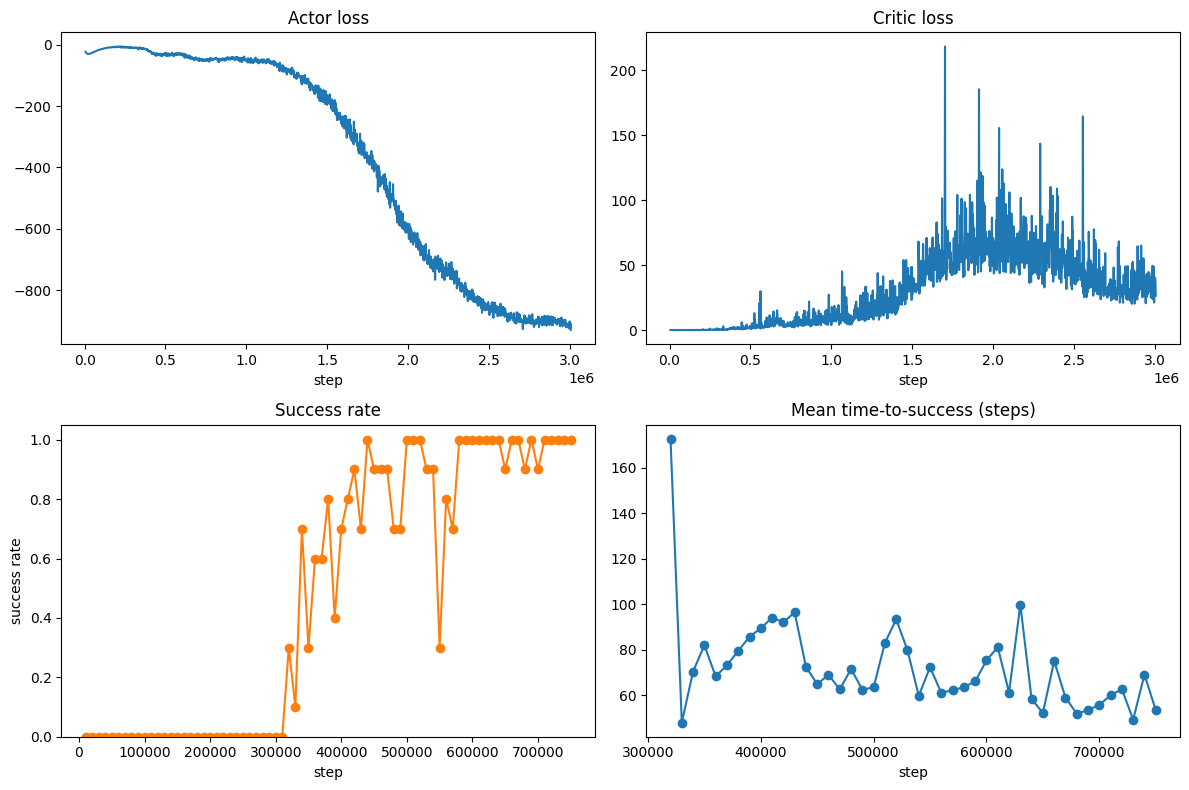

In [7]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import json
import pandas as pd
import matplotlib.pyplot as plt
import glob

# --- 1. Load TensorBoard scalars (actor/critic loss, reward) ---
run_dir = glob.glob("./tb_logs/peg_insert_side/sac_run1_*")[0]
ea = EventAccumulator(run_dir)
ea.Reload()

print("Available tags:", ea.Tags()["scalars"])

def scalar_to_df(tag):
    events = ea.Scalars(tag)
    return pd.DataFrame([(e.step, e.value) for e in events], columns=["step", "value"])

actor_loss_df = scalar_to_df("train/actor_loss")
critic_loss_df = scalar_to_df("train/critic_loss")
reward_df = scalar_to_df("rollout/ep_rew_mean")

# --- 2. Load eval_history.json (success rate, time2success) ---
with open("./checkpoints/peg_insert_side/eval_history.json") as f:
    eval_history = json.load(f)
eval_df = pd.DataFrame(eval_history)

# --- 3. Combined 2x2 diagnostic panel ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(actor_loss_df["step"], actor_loss_df["value"])
axes[0,0].set_title("Actor loss")
axes[0,0].set_xlabel("step")

axes[0,1].plot(critic_loss_df["step"], critic_loss_df["value"])
axes[0,1].set_title("Critic loss")
axes[0,1].set_xlabel("step")

# Success rate on its own axis, no reward overlay
axes[1,0].plot(eval_df["step"], eval_df["success_rate"], marker="o", color="tab:orange")
axes[1,0].set_title("Success rate")
axes[1,0].set_xlabel("step")
axes[1,0].set_ylabel("success rate")
axes[1,0].set_ylim(0, 1.05)

axes[1,1].plot(eval_df["step"], eval_df["mean_time_to_success"], marker="o")
axes[1,1].set_title("Mean time-to-success (steps)")
axes[1,1].set_xlabel("step")

plt.tight_layout()
plt.show()